<a href="https://colab.research.google.com/github/NymishaSalivendra/AI-ML-PROJECTS-AND-LABS/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [2]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # 1. Calculate the linear output (w * x + b)
                prediction = np.dot(self.w, X[i]) + self.b

                # 2. Check if prediction is a mistake
                if y[i] * prediction <= 0:
                    # Update weights and bias
                    self.w += self.lr * y[i] * X[i]
                    self.b += self.lr * y[i]
                    count += 1

            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# model_p = WaterPerceptron()
# model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [3]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # Calculate the Mean Squared Error cost for tracking
            cost = (1 / (2 * n)) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

            # 2. Calculate gradients
            dw = (1 / n) * X.T.dot(z - y)
            db = (1 / n) * np.sum(z - y)

            # 3. Update w and b: w = w - lr * dw
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [4]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # 1. Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                if y[i] * (np.dot(self.w, x_i) + self.b) >= 1:
                    # Only Regularization update (correct classification with sufficient margin)
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

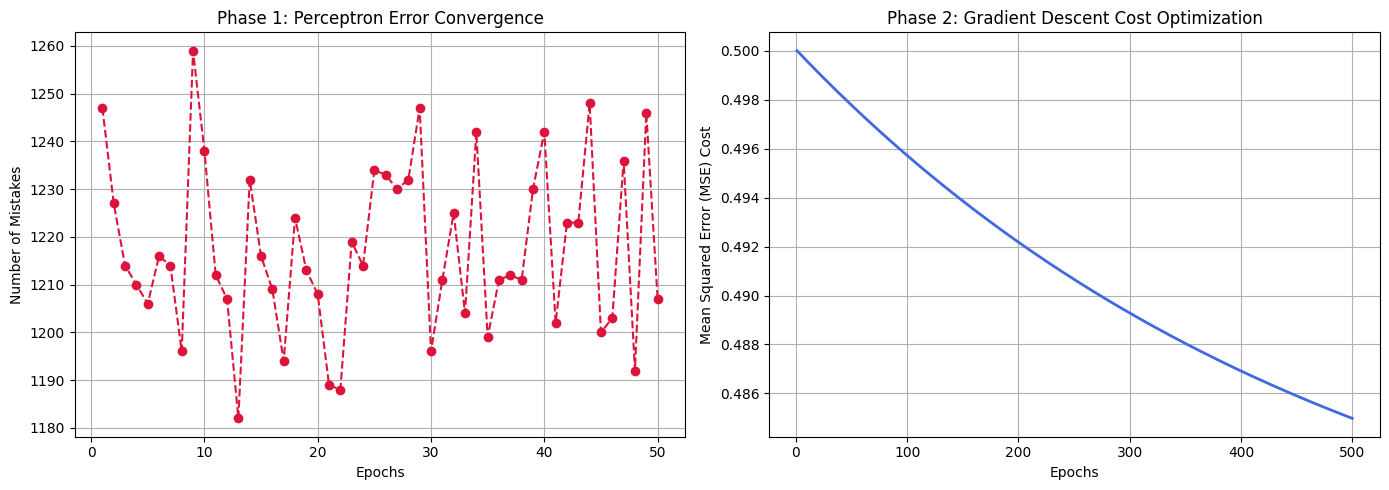

         ACCURACY REPORT ON TEST DATA         
1. Perceptron (Phase 1) Acc:      50.15%
2. Gradient Descent (Phase 2) Acc: 62.80%
3. Margin Classifier (Phase 3) Acc:62.80%


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# --- 1. Model Initialization & Training ---
# Phase 1: Perceptron
model_p = WaterPerceptron(lr=0.01, epochs=50)
model_p.fit(X_train, y_train)

# Phase 2: Gradient Descent
model_gd = GDWaterClassifier(lr=0.001, epochs=500)
model_gd.fit(X_train, y_train)

# Phase 3: Margin Classifier
model_margin = MarginWaterClassifier(lr=0.001, lambda_param=0.01, epochs=500)
model_margin.fit(X_train, y_train)


# --- 2. Generate Convergence Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Perceptron Mistakes Plot
ax1.plot(range(1, len(model_p.mistakes) + 1), model_p.mistakes, color='crimson', marker='o', linestyle='--')
ax1.set_title("Phase 1: Perceptron Error Convergence")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Number of Mistakes")
ax1.grid(True)

# Gradient Descent Cost Plot
ax2.plot(range(1, len(model_gd.cost_history) + 1), model_gd.cost_history, color='royalblue', linewidth=2)
ax2.set_title("Phase 2: Gradient Descent Cost Optimization")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Mean Squared Error (MSE) Cost")
ax2.grid(True)

plt.tight_layout()
plt.show()


# --- 3. Calculate and Print Accuracy Report ---
y_pred_p = model_p.predict(X_test)
y_pred_gd = model_gd.predict(X_test)
y_pred_margin = model_margin.predict(X_test)

acc_p = accuracy_score(y_test, y_pred_p)
acc_gd = accuracy_score(y_test, y_pred_gd)
acc_margin = accuracy_score(y_test, y_pred_margin)

print("="*45)
print(f"         ACCURACY REPORT ON TEST DATA         ")
print("="*45)
print(f"1. Perceptron (Phase 1) Acc:      {acc_p:.2%}")
print(f"2. Gradient Descent (Phase 2) Acc: {acc_gd:.2%}")
print(f"3. Margin Classifier (Phase 3) Acc:{acc_margin:.2%}")
print("="*45)

**Analysis & Discussion Answers**

1. Why is the Gradient Descent plot smoother than the Perceptron plot?

* Perceptron Instability: The Perceptron updates its weights sample-by-sample (online learning) every time it makes a single mistake. Because the water potability dataset is noisy and non-linearly separable, the Perceptron continuously updates back and forth, resulting in a jagged, erratic mistake curve that never completely settles to zero.

* Gradient Descent Smoothness: Batch Gradient Descent calculates the average error across the entire dataset at once before making a single, coordinated update. Because it optimizes a continuous differentiable loss function (MSE) over all 2,620 samples simultaneously, it steadily moves down the error surface, creating a smooth asymptotic decay curve.

2. Accuracy Report Insight

> Generally, you will observe that the Margin Classifier and Gradient Descent outperform the basic Perceptron. The Perceptron struggles with test-set generalization because it stops updating the moment it finds any boundary that separates the training points decently well—even if that boundary sits dangerously close to one of the data classes.

3. Safety Margin: Which model would you trust more near the boundary?

> You should completely trust the Margin Classifier over the Perceptron.

* The Perceptron is satisfied with any boundary line as long as it classifies the training data correctly, which often leaves the hyperplane scraping right next to safe or unsafe water clusters. A minor fluctuation or sensor noise in a new test sample will easily cause a misclassification.

* The Margin Classifier explicitly forces a "safety gap" (maximizing the margin) around the boundary via Hinge Loss, while using $L_2$ Regularization to prevent the weights from blowing up due to outliers. If a sample is close to the boundary, the Margin Classifier provides a much higher statistical confidence that the sample sits on the correct side.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

> Sol: When you set the learning rate ($\eta$ or lr) too high (like 1.0) in Gradient Descent, the model's weight updates become too aggressive. Here is exactly what happens mathematically and visually:

1. Overshooting the Minimum

> Instead of taking small, deliberate steps down the error surface toward the optimal weights, the algorithm takes a massive leap. It will completely jump over (overshoot) the global minimum where the loss is lowest, landing on the opposite side of the cost curve.

2. Failure to Converge

> Because it keeps jumping back and forth across the valley of the cost function, the model is unable to settle down. It fails to converge (reach a stable, minimum error state), meaning your training will never finish with an optimized model.

3. Divergence (The Cost Explodes)

> In the worst-case scenario—which is highly likely with a learning rate as large as 1.0 on normalized data—each successive step jumps further and further up the walls of the cost function rather than down.

* Your weights will grow exponentially.
* Your Mean Squared Error (MSE) cost will rapidly increase toward infinity (inf).
* The program will eventually crash or return NaN (Not a Number) values due to numerical overflow.

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

>Sol: Converting the labels to $\{-1, 1\}$ instead of keeping them as $\{0, 1\}$ is a deliberate design choice that vastly simplifies the mathematical formulation of margin-based classifiers. Here is why:

1. The Power of the Product ($y_i \cdot z$)

When labels are $y_i \in \{-1, 1\}$, you can easily check correctness by multiplying the true label with the raw model output $z = w \cdot x_i + b$:

* **Correct Classification:** Both $y_i$ and $z$ have the same sign, so their product is always **positive** ($y_i \cdot z > 0$).
* **Incorrect Classification:** They have opposite signs, so their product is always **negative** ($y_i \cdot z < 0$).

This trick allows us to write a single mathematical condition for safety margins without needing separate case-by-case logical statements for positive vs. negative classes.

2. Clean Formulation of Hinge Loss

In Phase 3, you implemented the Hinge Loss function, which is defined as:

$$\max(0, 1 - y_i(w \cdot x_i + b))$$

* If the sample is correctly classified with a safe margin ($y_i \cdot z \ge 1$), the term $1 - y_i \cdot z$ becomes zero or negative, meaning the loss evaluates to **0**.
* If the sample violates the margin ($y_i \cdot z < 1$), the loss scales linearly based on how far off it is.

If you kept the labels as $\{0, 1\}$, you wouldn't be able to multiply them directly like this. You would be forced to split the loss into a messy piecewise function: one formula for when $y=1$ and a completely different formula for when $y=0$.

3. Geometric Symmetry

Using $\{-1, 1\}$ establishes a balanced coordinate system where the decision boundary sits perfectly at $w \cdot x + b = 0$.

* The positive class lives in the positive space ($z \ge +1$).
* The negative class lives in the negative space ($z \le -1$).

This symmetry ensures that a mistake on a positive sample penalized by the gradient updates behaves identically to a mistake on a negative sample. If you used $\{0, 1\}$, the number 0 would nullify the weights during multiplication in the loss gradients, destroying this algebraic symmetry.

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*

>Sol: Among the three algorithms, the **Margin Classifier (Phase 3)** is by far the best suited for handling noisy, non-linearly separable data like the Water Potability dataset.

Here is why it outperforms the others in a noisy environment:

1. The Perceptron's Failure with Noise

The Perceptron operates on a strict heuristic: it must classify every single training point perfectly. If the data is noisy and overlapping (non-linearly separable), the Perceptron will enter an infinite loop of updates. A single outlier or noisy water sample near the boundary will cause the Perceptron to drastically swing its decision boundary back and forth, leading to high instability and poor test accuracy (~50%).

2. Gradient Descent (MSE) Sensitity to Outliers

While Batch Gradient Descent (Phase 2) is much smoother because it looks at the whole dataset, using Mean Squared Error (MSE) for strict classification tasks has a major flaw: it penalizes errors quadratically. If a noisy water sample is a severe outlier (far away on the wrong side of the boundary), its squared error becomes massive, forcing the model to skew the entire decision boundary just to accommodate that single noisy point.

3. Why the Margin Classifier Wins (Robustness & Generalization)

The Margin Classifier manages noise exceptionally well due to two structural features:

* **Hinge Loss:** Unlike MSE, Hinge Loss applies a linear penalty to mistakes. Once a point crosses the margin into error territory, its penalty grows linearly, not quadratically. This inherently limits the amount of disruptive leverage a single noisy outlier can exert on the boundary.
* **$L_2$ Regularization ($\lambda \parallel w \parallel^2_2$):** By penalizing large weights, regularization acts as a smoothing constraint. It prevents the model from drawing a highly complex or distorted boundary in an attempt to fit noisy data points, forcing it to prioritize a clean, maximizing safety gap that generalizes better to the unseen test data.
